**NAME - RUCHITA PANKAJ BODKE**\
**PRN - 202401110022**\
**BRANCH - CSE-AIML**\
**BATCH - A2**\
**COURSE - GENERATIVE AI**

**Practical - 03** -
Autoencoder and Variational Autoencoder for Image Reconstruction


---



**Problem Statement** -
Build an Autoencoder and a Variational Autoencoder (VAE) for image reconstruction and generation. Compare the performance of both models by analyzing the quality of reconstructed and generated images.

Dataset: MNIST\
MNIST is a collection of handwritten digit images commonly used for image classification and reconstruction tasks. It contains 70,000 grayscale images of digits from 0 to 9:
- 60,000 training images
- 10,000 test images
- Each image is 28 × 28 pixels and has a corresponding digit label.\

In this practical, the labels are not used to train the autoencoder or VAE. Each model learns to reconstruct the input image itself. The test set is held out during training so we can assess how well the models reconstruct unseen digits.

1. Imports and reproducibility

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

SEED = 42
LATENT_DIM = 16
BATCH_SIZE = 128
EPOCHS = 10

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


2. Download and prepare MNIST
ToTensor() scales the grayscale pixels to [0, 1], matching the sigmoid output used by both decoders.

In [2]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

# A fixed generator makes the shuffled training order reproducible.
generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=generator
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False
)

print(f"Training images: {len(train_dataset)}")
print(f"Test images: {len(test_dataset)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 458kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.15MB/s]


Training images: 60000
Test images: 10000


3. Define the autoencoder
The encoder compresses each 28 × 28 image into a 16-value latent vector. The decoder reconstructs the image from that vector.

In [3]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 28 * 28),
            nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)
        reconstruction = self.decoder(z).view(-1, 1, 28, 28)
        return reconstruction

4. Define the variational autoencoder
The VAE encoder predicts a mean and log variance for a latent probability distribution. The reparameterization step allows gradient-based training while sampling from that distribution.

In [4]:
class VariationalAutoencoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.features = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
        )
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 28 * 28),
            nn.Sigmoid(),
        )

    def encode(self, x):
        hidden = self.features(x)
        mu = self.fc_mu(hidden)
        logvar = self.fc_logvar(hidden).clamp(-12, 8)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std)
        return mu + std * epsilon

    def decode(self, z):
        return self.decoder(z).view(-1, 1, 28, 28)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decode(z)
        return reconstruction, mu, logvar

5. Set up models and loss functions
The AE minimizes reconstruction binary cross-entropy (BCE). The VAE minimizes BCE plus a KL-divergence term, which encourages its latent distributions to resemble a standard normal distribution.

In [5]:
ae = Autoencoder().to(device)
vae = VariationalAutoencoder().to(device)

ae_optimizer = torch.optim.Adam(ae.parameters(), lr=1e-3)
vae_optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)

def vae_loss_function(reconstruction, x, mu, logvar):
    # Sum pixel BCE across each image and then sum across the batch.
    reconstruction_loss = F.binary_cross_entropy(
        reconstruction, x, reduction="sum"
    )

    # KL divergence from q(z|x) to a standard normal prior N(0, I).
    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    total_loss = reconstruction_loss + kl_loss
    return total_loss, reconstruction_loss, kl_loss

6. Train both models

In [6]:
history = {
    "ae_loss": [],
    "vae_total": [],
    "vae_reconstruction": [],
    "vae_kl": [],
}

for epoch in range(1, EPOCHS + 1):
    # Train the autoencoder
    ae.train()
    ae_total = 0.0

    for images, _ in train_loader:
        images = images.to(device)

        ae_optimizer.zero_grad()
        reconstruction = ae(images)
        loss = F.binary_cross_entropy(reconstruction, images, reduction="sum")
        loss.backward()
        ae_optimizer.step()

        ae_total += loss.item()

    ae_epoch_loss = ae_total / len(train_dataset)

    # Train the variational autoencoder
    vae.train()
    vae_total = vae_reconstruction = vae_kl = 0.0

    for images, _ in train_loader:
        images = images.to(device)

        vae_optimizer.zero_grad()
        reconstruction, mu, logvar = vae(images)
        loss, reconstruction_loss, kl_loss = vae_loss_function(
            reconstruction, images, mu, logvar
        )
        loss.backward()
        vae_optimizer.step()

        vae_total += loss.item()
        vae_reconstruction += reconstruction_loss.item()
        vae_kl += kl_loss.item()

    vae_epoch_loss = vae_total / len(train_dataset)
    vae_recon_epoch = vae_reconstruction / len(train_dataset)
    vae_kl_epoch = vae_kl / len(train_dataset)

    history["ae_loss"].append(ae_epoch_loss)
    history["vae_total"].append(vae_epoch_loss)
    history["vae_reconstruction"].append(vae_recon_epoch)
    history["vae_kl"].append(vae_kl_epoch)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"AE BCE/image: {ae_epoch_loss:.2f} | "
        f"VAE total/image: {vae_epoch_loss:.2f} "
        f"(reconstruction: {vae_recon_epoch:.2f}, KL: {vae_kl_epoch:.2f})"
    )

Epoch 01/10 | AE BCE/image: 169.82 | VAE total/image: 192.65 (reconstruction: 186.64, KL: 6.01)
Epoch 02/10 | AE BCE/image: 108.15 | VAE total/image: 139.85 (reconstruction: 125.96, KL: 13.88)
Epoch 03/10 | AE BCE/image: 95.75 | VAE total/image: 124.94 (reconstruction: 109.02, KL: 15.93)
Epoch 04/10 | AE BCE/image: 88.96 | VAE total/image: 118.10 (reconstruction: 100.94, KL: 17.15)
Epoch 05/10 | AE BCE/image: 84.20 | VAE total/image: 114.41 (reconstruction: 96.45, KL: 17.96)
Epoch 06/10 | AE BCE/image: 80.77 | VAE total/image: 111.99 (reconstruction: 93.52, KL: 18.48)
Epoch 07/10 | AE BCE/image: 78.71 | VAE total/image: 110.20 (reconstruction: 91.37, KL: 18.83)
Epoch 08/10 | AE BCE/image: 77.26 | VAE total/image: 108.92 (reconstruction: 89.82, KL: 19.10)
Epoch 09/10 | AE BCE/image: 76.16 | VAE total/image: 107.90 (reconstruction: 88.63, KL: 19.27)
Epoch 10/10 | AE BCE/image: 75.26 | VAE total/image: 107.13 (reconstruction: 87.72, KL: 19.41)


7. Plot training losses
The AE and VAE total losses have different components, so use this plot to observe training progress rather than treating their values as a direct quality ranking.

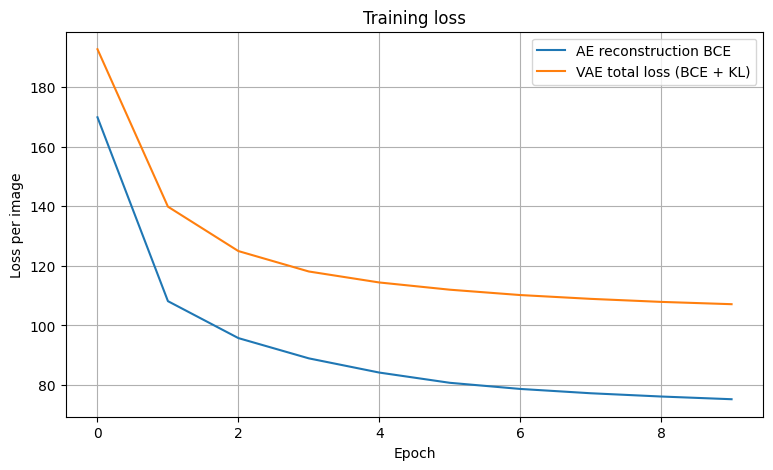

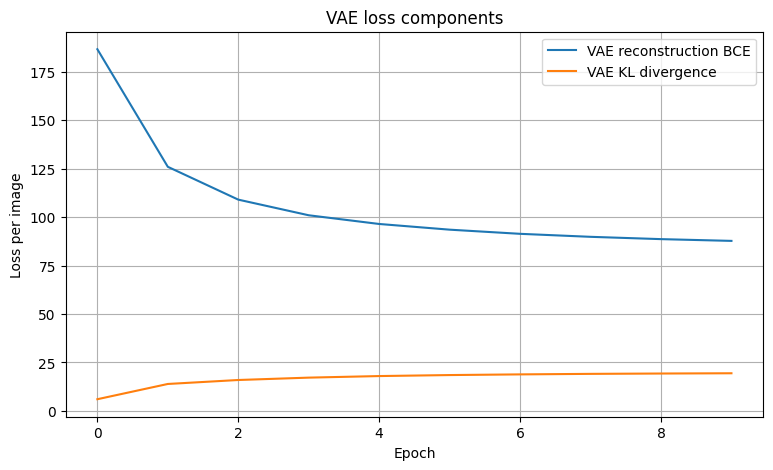

In [7]:
plt.figure(figsize=(9, 5))
plt.plot(history["ae_loss"], label="AE reconstruction BCE")
plt.plot(history["vae_total"], label="VAE total loss (BCE + KL)")
plt.xlabel("Epoch")
plt.ylabel("Loss per image")
plt.title("Training loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(history["vae_reconstruction"], label="VAE reconstruction BCE")
plt.plot(history["vae_kl"], label="VAE KL divergence")
plt.xlabel("Epoch")
plt.ylabel("Loss per image")
plt.title("VAE loss components")
plt.legend()
plt.grid(True)
plt.show()

8. Compare original and reconstructed test images
For the VAE reconstruction comparison, this decodes the predicted mean μ. That makes the reconstruction display stable and comparable across runs.

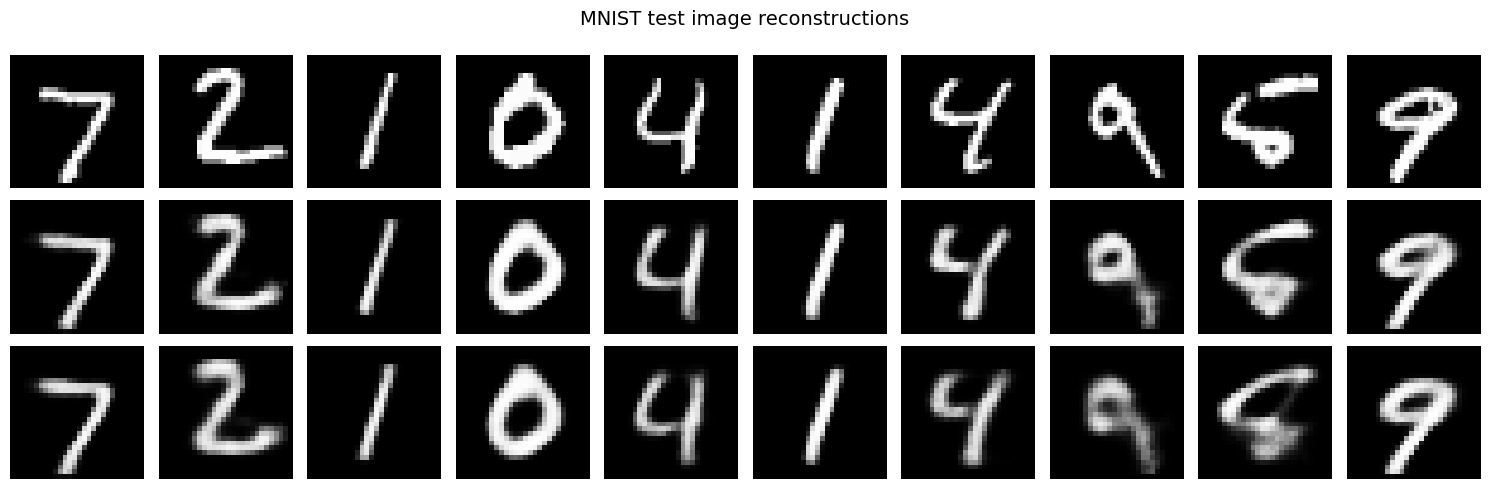

Digit labels: [7, 2, 1, 0, 4, 1, 4, 9, 5, 9]


In [8]:
@torch.no_grad()
def get_test_reconstructions():
    ae.eval()
    vae.eval()

    images, labels = next(iter(test_loader))
    images = images[:10].to(device)
    labels = labels[:10]

    ae_recon = ae(images)

    mu, _ = vae.encode(images)
    vae_recon = vae.decode(mu)

    return images.cpu(), ae_recon.cpu(), vae_recon.cpu(), labels

originals, ae_recons, vae_recons, labels = get_test_reconstructions()

fig, axes = plt.subplots(3, 10, figsize=(15, 5))
row_titles = ["Original", "Autoencoder", "VAE (posterior mean)"]
rows = [originals, ae_recons, vae_recons]

for row in range(3):
    for col in range(10):
        axes[row, col].imshow(rows[row][col, 0], cmap="gray", vmin=0, vmax=1)
        axes[row, col].axis("off")
    axes[row, 0].set_ylabel(row_titles[row], rotation=0, labelpad=75, va="center")

fig.suptitle("MNIST test image reconstructions", fontsize=14)
plt.tight_layout()
plt.show()

print("Digit labels:", labels.tolist())

9. Generate new images
A VAE is trained to make samples from N(0, I) decodable, so sample random latent vectors from that distribution. The AE has no such prior-matching objective; the AE examples below decode latent codes from real training images and are not unconditional random samples.

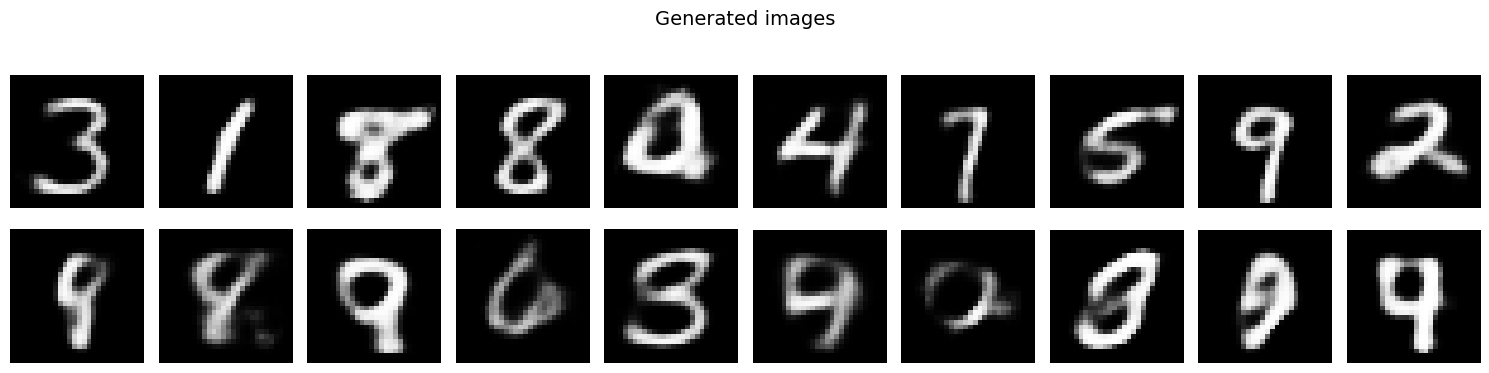

In [9]:
@torch.no_grad()
def show_generated_images():
    ae.eval()
    vae.eval()

    # AE: encode actual training examples, then decode those codes.
    train_images, _ = next(iter(train_loader))
    ae_codes = ae.encoder(train_images[:10].to(device))
    ae_generated = ae.decoder(ae_codes).view(-1, 1, 28, 28)

    # VAE: sample from the prior distribution it was trained to match.
    z = torch.randn(10, LATENT_DIM, device=device)
    vae_generated = vae.decode(z)

    fig, axes = plt.subplots(2, 10, figsize=(15, 4))
    rows = [ae_generated.cpu(), vae_generated.cpu()]
    titles = ["AE: encoded training images", "VAE: prior samples N(0, I)"]

    for row in range(2):
        for col in range(10):
            axes[row, col].imshow(rows[row][col, 0], cmap="gray", vmin=0, vmax=1)
            axes[row, col].axis("off")
        axes[row, 0].set_ylabel(titles[row], rotation=0, labelpad=100, va="center")

    fig.suptitle("Generated images", fontsize=14)
    plt.tight_layout()
    plt.show()

show_generated_images()

10. Calculate held-out reconstruction metrics
MSE is the mean squared pixel error. BCE is the reconstruction objective used in training. VAE metrics here also use the posterior mean so repeated evaluation is deterministic.

In [10]:
@torch.no_grad()
def evaluate_reconstruction(model, loader, is_vae=False):
    model.eval()
    squared_error = 0.0
    bce_sum = 0.0
    pixel_count = 0
    image_count = 0

    for images, _ in loader:
        images = images.to(device)

        if is_vae:
            mu, _ = model.encode(images)
            reconstruction = model.decode(mu)
        else:
            reconstruction = model(images)

        squared_error += F.mse_loss(
            reconstruction, images, reduction="sum"
        ).item()
        bce_sum += F.binary_cross_entropy(
            reconstruction, images, reduction="sum"
        ).item()

        pixel_count += images.numel()
        image_count += images.size(0)

    return {
        "MSE per pixel": squared_error / pixel_count,
        "BCE per image": bce_sum / image_count,
    }

ae_metrics = evaluate_reconstruction(ae, test_loader)
vae_metrics = evaluate_reconstruction(vae, test_loader, is_vae=True)

print("Autoencoder test metrics:", ae_metrics)
print("VAE test metrics:", vae_metrics)

Autoencoder test metrics: {'MSE per pixel': 0.011049520635604859, 'BCE per image': 74.63099086914063}
VAE test metrics: {'MSE per pixel': 0.013854256847926549, 'BCE per image': 81.52632514648438}


11. Save results
This saves the model weights and metric values to the Colab session.

In [11]:
import json

torch.save(
    {
        "autoencoder": ae.state_dict(),
        "vae": vae.state_dict(),
        "latent_dim": LATENT_DIM,
        "seed": SEED,
    },
    "ae_vae_mnist_models.pth",
)

with open("ae_vae_mnist_metrics.json", "w") as f:
    json.dump(
        {"AE": ae_metrics, "VAE": vae_metrics, "seed": SEED, "epochs": EPOCHS},
        f,
        indent=2,
    )

print("Saved ae_vae_mnist_models.pth and ae_vae_mnist_metrics.json")

Saved ae_vae_mnist_models.pth and ae_vae_mnist_metrics.json
